# Preliminary Clinical Imaging Assistant using Qwen2-VL

## Objective

This project implements an open-source Vision-Language Model (VLM) as a preliminary clinical imaging assistant using the free Google Colab environment.

### Selected Model
- Model: Qwen2-VL-2B-Instruct
- Source: Hugging Face
- Hardware Target: Google Colab NVIDIA T4 GPU
- Quantization: 4-bit NF4 using BitsAndBytes

### Requirements Covered

1. Select and justify an open-source Vision-Language Model.
2. Load the model using memory-efficient 4-bit quantization.
3. Create a reusable multimodal inference function.
4. Design a clinical imaging system prompt.
5. Run inference on at least two publicly available medical images.
6. Document sample outputs, design choices, and limitations.

> **Important:** This project is an educational demonstration only. The model is not intended for clinical diagnosis or treatment decisions.

In [1]:
# ============================================================
# CELL 2: HARDWARE CHECK
# ============================================================

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    print("WARNING: GPU is not available.")
    print("In Colab, go to Runtime > Change runtime type > T4 GPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [4]:
# ============================================================
# CELL 3: INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q -U \
    "transformers>=4.45.0" \
    "accelerate>=0.34.0" \
    "bitsandbytes>=0.43.0" \
    "pillow>=10.0.0" \
    "requests>=2.31.0"

print("✅ Required packages installed.")

✅ Required packages installed.


In [7]:
!pip uninstall -y pillow
!pip install -U --no-cache-dir pillow

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.6 MB/s eta 0:00:00


# 1. Model Selection

## Qwen2-VL-2B-Instruct

I selected **Qwen2-VL-2B-Instruct** because it provides multimodal vision-language capabilities while being substantially smaller than many modern large VLMs.

The model is appropriate for this assignment because:

- It accepts both images and natural-language instructions.
- It can perform image understanding and visual question answering.
- The 2B parameter size is relatively lightweight for a Vision-Language Model.
- 4-bit quantization significantly reduces GPU memory requirements.
- It can therefore be demonstrated on a free Google Colab NVIDIA T4 GPU.
- It is available as an open model through Hugging Face.

## Why not a larger VLM?

Larger vision-language models can provide stronger reasoning performance but may exceed the memory constraints of a free Colab GPU. A 2B parameter model provides a practical balance between multimodal capability and resource requirements.

## Important limitation

Qwen2-VL-2B-Instruct is a general-purpose VLM, not a medical-specific foundation model. Therefore, its output should be treated as a preliminary visual description rather than a medical diagnosis.

In [1]:
# ============================================================
# CELL 5: IMPORTS AND 4-BIT QUANTIZATION CONFIGURATION
# ============================================================

import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

# Automatically select a supported computation dtype.
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    compute_dtype = torch.bfloat16
else:
    compute_dtype = torch.float16

print("Selected compute dtype:", compute_dtype)

# 4-bit BitsAndBytes configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype
)

print("✅ 4-bit NF4 quantization configured.")

Selected compute dtype: torch.bfloat16
✅ 4-bit NF4 quantization configured.


In [2]:
# ============================================================
# CELL 6: LOAD QWEN2-VL MODEL AND PROCESSOR
# ============================================================

print("Loading model...")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype
)

processor = AutoProcessor.from_pretrained(MODEL_ID)

model.eval()

print("✅ Model loaded successfully.")
print("Model:", MODEL_ID)
print("Compute dtype:", compute_dtype)

# Check where the first model parameter is located
first_param = next(model.parameters())
print("Model parameter device:", first_param.device)

# Optional GPU memory information
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3

    print(f"GPU memory allocated: {allocated:.2f} GB")
    print(f"GPU memory reserved:  {reserved:.2f} GB")

Loading model...


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

✅ Model loaded successfully.
Model: Qwen/Qwen2-VL-2B-Instruct
Compute dtype: torch.bfloat16
Model parameter device: cuda:0
GPU memory allocated: 1.42 GB
GPU memory reserved:  1.47 GB


In [3]:
# ============================================================
# CELL 7: CLINICAL SYSTEM PROMPT
# ============================================================

CLINICAL_SYSTEM_PROMPT = """
You are a Preliminary Clinical Imaging Assistant.

Your role is to provide a cautious, structured visual assessment of
medical images for educational and preliminary screening support.

You are NOT a doctor and must NOT provide a definitive diagnosis,
treatment recommendation, medication recommendation, or emergency
medical advice.

Analyze only what can reasonably be inferred from the provided image.
Do not invent patient history, symptoms, laboratory values, or findings
that are not visible in the image.

Follow this structure:

1. IMAGE TYPE AND QUALITY
- Identify the likely imaging modality.
- Identify the apparent view or projection when possible.
- Comment on image quality, positioning, exposure, focus, or visibility
  when relevant.
- If something cannot be determined, explicitly say so.

2. KEY VISUAL OBSERVATIONS
- Describe visible anatomical structures.
- Identify notable abnormalities or suspicious regions.
- Mention location, size, shape, margins, density, symmetry, or other
  relevant visual characteristics when appropriate.
- Distinguish between observed findings and uncertain interpretations.

3. PRELIMINARY DIFFERENTIAL CONSIDERATIONS
- Provide up to 2-3 possible explanations only when supported by the
  visual appearance.
- Clearly label these as possibilities rather than diagnoses.
- Do not claim certainty.

4. LIMITATIONS
- State important limitations caused by image quality, missing clinical
  history, modality limitations, or model uncertainty.

5. RECOMMENDED HUMAN REVIEW
- Recommend review by an appropriately qualified healthcare professional.
- Do not recommend a specific treatment.

Always end with exactly:

DISCLAIMER: This assessment is generated by an automated AI screening
framework for preliminary assistance only. It does not constitute a
definitive medical diagnosis and must be fully evaluated and signed off
by a certified medical practitioner before initiating any therapeutic
workflow.
"""

print("✅ Clinical system prompt loaded.")

✅ Clinical system prompt loaded.


In [5]:
from pathlib import Path

DATA_DIR = Path("/content/medical_images")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Image directory:", DATA_DIR)

Image directory: /content/medical_images


In [7]:
import requests
from PIL import Image

CHEST_XRAY_URL = (
    "https://commons.wikimedia.org/wiki/Special:Redirect/"
    "file/Chest_Xray_PA_3-8-2010.png"
)

CHEST_XRAY_PATH = DATA_DIR / "chest_xray.png"


def download_image(url, output_path):
    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=60
    )

    response.raise_for_status()

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(
        f"✅ Saved: {output_path} "
        f"({output_path.stat().st_size / 1024:.1f} KB)"
    )


download_image(
    CHEST_XRAY_URL,
    CHEST_XRAY_PATH
)

# Verify the image
xray = Image.open(CHEST_XRAY_PATH)

print("\nImage verification:")
print("Format:", xray.format)
print("Size:", xray.size)
print("Mode:", xray.mode)

✅ Saved: /content/medical_images/chest_xray.png (4099.6 KB)

Image verification:
Format: PNG
Size: (2412, 1956)
Mode: RGBA


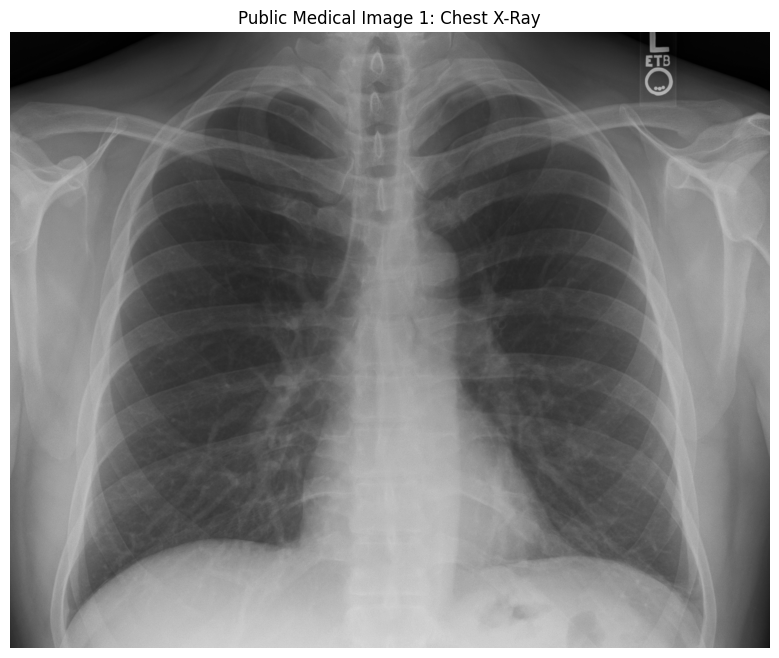

In [8]:
import matplotlib.pyplot as plt

image = Image.open(CHEST_XRAY_PATH)

plt.figure(figsize=(10, 8))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Public Medical Image 1: Chest X-Ray")
plt.show()

In [9]:
# ============================================================
# IMAGE 2: BRAIN MRI
# ============================================================

BRAIN_MRI_URL = (
    "https://commons.wikimedia.org/wiki/Special:Redirect/"
    "file/Brain_MRI.jpg"
)

BRAIN_MRI_PATH = DATA_DIR / "brain_mri.jpg"

download_image(
    BRAIN_MRI_URL,
    BRAIN_MRI_PATH
)

# Verify the image
brain_mri = Image.open(BRAIN_MRI_PATH)

print("\nImage 2 verification:")
print("Format:", brain_mri.format)
print("Size:", brain_mri.size)
print("Mode:", brain_mri.mode)

✅ Saved: /content/medical_images/brain_mri.jpg (2441.7 KB)

Image 2 verification:
Format: JPEG
Size: (2700, 1800)
Mode: RGB


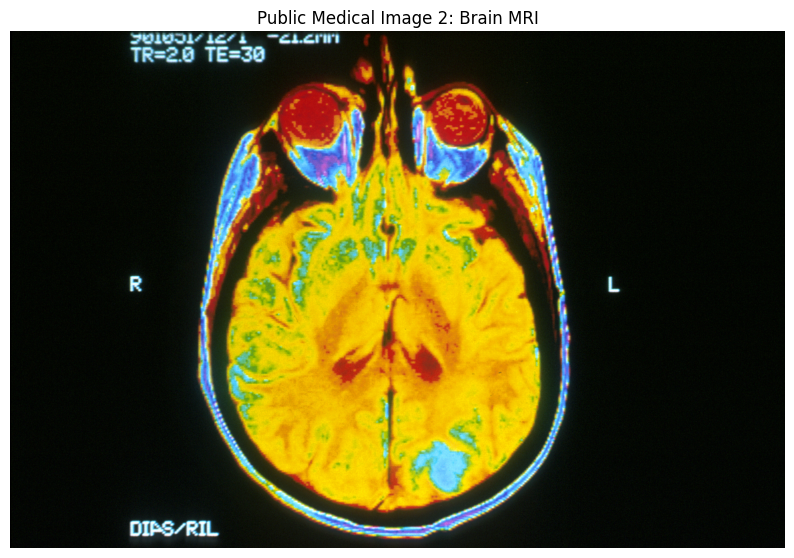

In [11]:
image = brain_mri

plt.figure(figsize=(10, 8))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Public Medical Image 2: Brain MRI")
plt.show()

In [18]:
def load_image(image_input, max_size=1024):
    """
    Load an image from a local path or URL.

    The image is resized before being passed to the VLM.
    This prevents extremely large medical images from generating
    excessive visual tokens and consuming too much GPU memory.
    """

    if str(image_input).startswith(("http://", "https://")):

        response = requests.get(
            image_input,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=60
        )

        response.raise_for_status()

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")

    else:

        image = Image.open(
            image_input
        ).convert("RGB")

    original_size = image.size

    # Resize while preserving aspect ratio
    image.thumbnail(
        (max_size, max_size),
        Image.Resampling.LANCZOS
    )

    print("Original image size:", original_size)
    print("Image size used by model:", image.size)

    return image

In [19]:
def run_clinical_inference(
    image_input,
    user_query,
    max_image_size=1024,
    max_new_tokens=256
):
    """
    Reusable inference function for preliminary clinical image analysis.

    Parameters
    ----------
    image_input : str or Path
        Local image path or public image URL.

    user_query : str
        Clinical question/instruction for the model.

    max_image_size : int
        Maximum image dimension used during inference.

    max_new_tokens : int
        Maximum number of tokens generated.

    Returns
    -------
    str
        Model-generated preliminary analysis.
    """

    # ---------------------------------------------------------------
    # 1. Load and resize image
    # ---------------------------------------------------------------

    image = load_image(
        image_input,
        max_size=max_image_size
    )

    print("\nRunning model inference...")

    # ---------------------------------------------------------------
    # 2. Build multimodal conversation
    # ---------------------------------------------------------------

    messages = [
        {
            "role": "system",
            "content": CLINICAL_SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image
                },
                {
                    "type": "text",
                    "text": user_query
                }
            ]
        }
    ]

    # ---------------------------------------------------------------
    # 3. Convert conversation to model prompt
    # ---------------------------------------------------------------

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # ---------------------------------------------------------------
    # 4. Prepare multimodal inputs
    # ---------------------------------------------------------------

    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt"
    )

    # Move tensors to model's device
    for key in inputs:
        if hasattr(inputs[key], "to"):
            inputs[key] = inputs[key].to(model.device)

    # ---------------------------------------------------------------
    # 5. Generate output
    # ---------------------------------------------------------------

    with torch.inference_mode():

        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    # ---------------------------------------------------------------
    # 6. Remove prompt tokens from generated sequence
    # ---------------------------------------------------------------

    input_token_length = inputs["input_ids"].shape[1]

    generated_ids = generated_ids[
        :,
        input_token_length:
    ]

    # ---------------------------------------------------------------
    # 7. Decode model output
    # ---------------------------------------------------------------

    output = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0]

    # ---------------------------------------------------------------
    # 8. Clean GPU memory
    # ---------------------------------------------------------------

    del inputs
    del generated_ids
    del image

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return output.strip()

In [20]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print("=" * 70)
    print("GPU MEMORY BEFORE INFERENCE")
    print("=" * 70)

    print(
        "Allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

    print(
        "Reserved:",
        round(torch.cuda.memory_reserved() / 1024**3, 2),
        "GB"
    )

    print(
        "Total:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

GPU MEMORY BEFORE INFERENCE
Allocated: 1.43 GB
Reserved: 1.49 GB
Total: 14.56 GB


In [25]:
print("=" * 70)
print("IMAGE 1: BRAIN MRI")
print("=" * 70)

xray_analysis = run_clinical_inference(
    image_input=str(BRAIN_MRI_PATH),

    user_query=(
        "Please provide a systematic preliminary assessment of this "
        "brain MRI. Describe the image quality and view, visible "
        "anatomy, important observations, possible differential "
        "considerations, and limitations."
    ),

    # Memory-safe settings for Colab T4
    max_image_size=1024,
    max_new_tokens=256
)

print("\n")
print("=" * 70)
print("MODEL OUTPUT")
print("=" * 70)
print(xray_analysis)

IMAGE 1: BRAIN MRI
Original image size: (2700, 1800)
Image size used by model: (1024, 683)

Running model inference...


MODEL OUTPUT
1. IMAGE TYPE AND QUALITY
- The image is a brain MRI scan, likely acquired using a magnetic resonance imaging (MRI) machine.
- The scan is a coronal view, showing the brain from the front.
- The image quality appears to be good, with clear visibility of the brain structures.
- The view is centered, with no apparent tilt or rotation.

2. KEY VISUAL OBSERVATIONS
- The brain appears to be healthy with no visible abnormalities.
- The ventricles are well-defined, and there are no signs of hydrocephalus.
- The cerebral hemispheres are symmetrical and appear to be of normal size.
- The gray and white matter is well-defined, with no signs of edema or mass effect.
- The basal ganglia and cerebellum are visible, with no signs of abnormal signal intensity or enhancement.

3. PRELIMINARY DIFFERENTIAL CONSIDERATIONS
- The absence of abnormal signal intensity or enhan

In [24]:
print("=" * 70)
print("IMAGE 1: CHEST X-RAY")
print("=" * 70)

xray_analysis = run_clinical_inference(
    image_input=str(CHEST_XRAY_PATH),

    user_query=(
        "Please provide a systematic preliminary assessment of this "
        "chest radiograph. Describe the image quality and view, visible "
        "anatomy, important observations, possible differential "
        "considerations, and limitations."
    ),

    # Memory-safe settings for Colab T4
    max_image_size=1024,
    max_new_tokens=256
)

print("\n")
print("=" * 70)
print("MODEL OUTPUT")
print("=" * 70)
print(xray_analysis)

IMAGE 1: CHEST X-RAY
Original image size: (2412, 1956)
Image size used by model: (1024, 830)

Running model inference...


MODEL OUTPUT
1. IMAGE TYPE AND QUALITY
- The image is a chest X-ray.
- The view is a frontal (anteroposterior) projection.
- The image quality appears to be good, with clear visibility of the anatomical structures.
- The patient's shoulders are slightly off-center, which is common in frontal X-rays.

2. KEY VISUAL OBSERVATIONS
- The lungs appear to be clear and symmetric.
- The heart is centrally located, with no obvious signs of enlargement or displacement.
- The diaphragm appears to be well-defined, with no signs of pleural effusion.
- The ribs are visible, with no obvious fractures or deformities.
- The spine is intact, with no signs of spinal cord compression.

3. PRELIMINARY DIFFERENTIAL CONSIDERATIONS
- Possible normal variants: The lungs may appear slightly more opaque than usual due to the patient's age or the presence of air in the lungs.
- Possible normal

In [26]:
import gc
import torch

print("=" * 70)
print("CLEARING GPU MEMORY")
print("=" * 70)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        "GPU memory allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

    print(
        "GPU memory reserved:",
        round(torch.cuda.memory_reserved() / 1024**3, 2),
        "GB"
    )

print("\nMemory cleanup completed.")

CLEARING GPU MEMORY
GPU memory allocated: 1.43 GB
GPU memory reserved: 1.49 GB

Memory cleanup completed.


# Design Choices

## 1. Model Selection

Qwen2-VL-2B-Instruct was selected because it provides multimodal image-and-text understanding while remaining relatively lightweight compared with larger VLMs.

The 2B parameter scale makes it more appropriate for experimentation in a free Google Colab environment.

## 2. 4-bit Quantization

The model is loaded using BitsAndBytes 4-bit quantization with:

- NF4 quantization
- Double quantization
- Reduced computation memory requirements

This significantly reduces the GPU memory required to load the model.

## 3. Automatic Device Mapping

`device_map="auto"` allows Hugging Face Accelerate to determine how model components should be placed on available hardware.

This makes the notebook easier to run across compatible Colab GPU environments.

## 4. Reusable Inference Function

The `run_clinical_inference()` function separates image loading, multimodal prompt construction, preprocessing, generation, decoding, and memory cleanup.

This allows the same function to be reused with different medical images.

## 5. Conservative Clinical Prompt

The system prompt explicitly prevents the model from presenting its output as a definitive medical diagnosis.

The model is instructed to:

- describe observations,
- identify uncertainty,
- provide possible differential considerations,
- explain limitations,
- recommend professional review.

## 6. Deterministic Generation

Sampling is disabled using:

```python
do_sample=False


---

# Cell 15 — Limitations and safety

**Markdown cell**

```markdown
# Limitations and Safety Considerations

## 1. General-Purpose Model

Qwen2-VL-2B-Instruct is a general-purpose vision-language model rather than a dedicated medical imaging model.

Its medical imaging performance should therefore not be assumed to match specialized radiology or dermatology systems.

## 2. Hallucination

Vision-language models can generate plausible-sounding statements that are not supported by the image.

For this reason, model-generated observations must be independently verified.

## 3. No Patient Context

The model only receives the image and the provided text prompt.

It does not have access to:

- patient history,
- symptoms,
- laboratory results,
- previous imaging,
- clinical examination,
- demographic information.

These factors can be essential for real clinical interpretation.

## 4. Image Quality

Poor resolution, compression, incorrect positioning, lighting problems, artifacts, or incomplete anatomical coverage can significantly affect model performance.

## 5. Diagnostic Limitations

The model should not be used as an autonomous diagnostic system.

It should not be used to:

- establish a final diagnosis,
- prescribe treatment,
- determine medication,
- replace a radiologist, dermatologist, physician, or other qualified professional.

## 6. Dataset and Bias Limitations

The model may perform differently across different patient populations, imaging devices, modalities, skin tones, acquisition protocols, and clinical settings.

## 7. Educational Demonstration

This notebook demonstrates how an open-source VLM can be integrated into a preliminary medical-image analysis workflow.

It is not a validated clinical decision-support system.

# Conclusion

This project demonstrates an end-to-end preliminary clinical imaging workflow using Qwen2-VL-2B-Instruct.

The implementation:

- Uses an open-source Vision-Language Model.
- Runs with 4-bit quantization to reduce GPU memory requirements.
- Uses a reusable multimodal inference function.
- Applies a structured clinical imaging system prompt.
- Processes multiple publicly available medical images.
- Produces structured preliminary observations and differential considerations.
- Explicitly communicates uncertainty and clinical limitations.

The resulting system demonstrates the technical feasibility of running a lightweight multimodal model for educational medical-image analysis within a constrained Google Colab environment.

However, the generated outputs must not be interpreted as medical diagnoses and require qualified human review.